In [54]:
import pandas as pd

In [55]:
import pandas as pd

movies = pd.read_csv(r"C:\Users\naina\Downloads\ml-latest-small\ml-latest-small\movies.csv")
ratings = pd.read_csv(r"C:\Users\naina\Downloads\ml-latest-small\ml-latest-small\ratings.csv")
tags = pd.read_csv(r"C:\Users\naina\Downloads\ml-latest-small\ml-latest-small\tags.csv")
links = pd.read_csv(r"C:\Users\naina\Downloads\ml-latest-small\ml-latest-small\links.csv")

In [56]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [57]:
print("Movies:", movies.shape)
print("Ratings:", ratings.shape)
print("Tags:", tags.shape)
print("Links:", links.shape)

Movies: (9742, 3)
Ratings: (100836, 4)
Tags: (3683, 4)
Links: (9742, 3)


In [58]:
print("Movies Columns:", movies.columns)
print("Ratings Columns:", ratings.columns)
print("Tags Columns:", tags.columns)
print("Links Columns:", links.columns)

Movies Columns: Index(['movieId', 'title', 'genres'], dtype='object')
Ratings Columns: Index(['userId', 'movieId', 'rating', 'timestamp'], dtype='object')
Tags Columns: Index(['userId', 'movieId', 'tag', 'timestamp'], dtype='object')
Links Columns: Index(['movieId', 'imdbId', 'tmdbId'], dtype='object')


In [59]:
print("Movies Data Types:")
print(movies.dtypes)

print("\nRatings Data Types:")
print(ratings.dtypes)

print("\nTags Data Types:")
print(tags.dtypes)

print("\nLinks Data Types:")
print(links.dtypes)

Movies Data Types:
movieId     int64
title      object
genres     object
dtype: object

Ratings Data Types:
userId         int64
movieId        int64
rating       float64
timestamp      int64
dtype: object

Tags Data Types:
userId        int64
movieId       int64
tag          object
timestamp     int64
dtype: object

Links Data Types:
movieId      int64
imdbId       int64
tmdbId     float64
dtype: object


In [60]:
print("Movies:")
print(movies.isnull().sum())

print("\nRatings:")
print(ratings.isnull().sum())

print("\nTags:")
print(tags.isnull().sum())

print("\nLinks:")
print(links.isnull().sum())

Movies:
movieId    0
title      0
genres     0
dtype: int64

Ratings:
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

Tags:
userId       0
movieId      0
tag          0
timestamp    0
dtype: int64

Links:
movieId    0
imdbId     0
tmdbId     8
dtype: int64


In [61]:
print("Movies Duplicates:", movies.duplicated().sum())
print("Ratings Duplicates:", ratings.duplicated().sum())
print("Tags Duplicates:", tags.duplicated().sum())
print("Links Duplicates:", links.duplicated().sum())

Movies Duplicates: 0
Ratings Duplicates: 0
Tags Duplicates: 0
Links Duplicates: 0


In [62]:
print(ratings.describe())

              userId        movieId         rating     timestamp
count  100836.000000  100836.000000  100836.000000  1.008360e+05
mean      326.127564   19435.295718       3.501557  1.205946e+09
std       182.618491   35530.987199       1.042529  2.162610e+08
min         1.000000       1.000000       0.500000  8.281246e+08
25%       177.000000    1199.000000       3.000000  1.019124e+09
50%       325.000000    2991.000000       3.500000  1.186087e+09
75%       477.000000    8122.000000       4.000000  1.435994e+09
max       610.000000  193609.000000       5.000000  1.537799e+09


In [63]:
print("Number of Unique Users:", ratings["userId"].nunique())
print("Number of Unique Movies:", movies["movieId"].nunique())

Number of Unique Users: 610
Number of Unique Movies: 9742


In [64]:
print(ratings["rating"].value_counts().sort_index())

rating
0.5     1370
1.0     2811
1.5     1791
2.0     7551
2.5     5550
3.0    20047
3.5    13136
4.0    26818
4.5     8551
5.0    13211
Name: count, dtype: int64


In [65]:
print("Common column between all datasets: movieId")
print("movies.csv + ratings.csv -> movieId")
print("movies.csv + tags.csv -> movieId")
print("movies.csv + links.csv -> movieId")
print("ratings.csv + tags.csv -> userId and movieId")

Common column between all datasets: movieId
movies.csv + ratings.csv -> movieId
movies.csv + tags.csv -> movieId
movies.csv + links.csv -> movieId
ratings.csv + tags.csv -> userId and movieId


Day-3: Data Preprocessing

In [66]:
master_df = ratings.merge(movies, on="movieId", how="left")
master_df = master_df.merge(links, on="movieId", how="left")
master_df = master_df.merge(tags, on=["userId", "movieId"], how="left")
master_df.head()

,userId,movieId,rating,timestamp_x,title,genres,imdbId,tmdbId,tag,timestamp_y
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,114709,862.0,NaN,NaN
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance,113228,15602.0,NaN,NaN
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller,113277,949.0,NaN,NaN
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller,114369,807.0,NaN,NaN
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller,114814,629.0,NaN,NaN


In [67]:
print("Duplicate rows before:", master_df.duplicated().sum())
master_df = master_df.drop_duplicates()
print("Duplicate rows after:", master_df.duplicated().sum())

Duplicate rows before: 0
Duplicate rows after: 0


In [68]:
print(master_df.isnull().sum())

userId             0
movieId            0
rating             0
timestamp_x        0
title              0
genres             0
imdbId             0
tmdbId            13
tag            99201
timestamp_y    99201
dtype: int64


In [69]:
master_df["tag"] = master_df["tag"].fillna("No Tag")
master_df = master_df.dropna(subset=["tmdbId"])
master_df.isnull().sum()

userId             0
movieId            0
rating             0
timestamp_x        0
title              0
genres             0
imdbId             0
tmdbId             0
tag                0
timestamp_y    99188
dtype: int64

In [70]:
master_df["timestamp_y"] = master_df["timestamp_y"].fillna(0)
master_df.isnull().sum()

userId         0
movieId        0
rating         0
timestamp_x    0
title          0
genres         0
imdbId         0
tmdbId         0
tag            0
timestamp_y    0
dtype: int64

In [71]:
master_df["timestamp_x"] = pd.to_datetime(master_df["timestamp_x"], unit="s")
master_df["timestamp_y"] = pd.to_datetime(master_df["timestamp_y"], unit="s")
master_df.dtypes

userId                  int64
movieId                 int64
rating                float64
timestamp_x    datetime64[ns]
title                  object
genres                 object
imdbId                  int64
tmdbId                float64
tag                    object
timestamp_y    datetime64[ns]
dtype: object

Feature Exploration

In [72]:
print("Total Movies:", master_df["movieId"].nunique())
print("Total Users:", master_df["userId"].nunique())
print("Total Ratings:", len(master_df))
print("\nTop 10 Most Rated Movies:")
print(master_df["title"].value_counts().head(10))
average_ratings = master_df.groupby("title")["rating"].mean().sort_values(ascending=False)
print("\nAverage Rating of Each Movie:")
print(average_ratings.head(10))
movie_stats = master_df.groupby("title").agg(
    average_rating=("rating", "mean"),
    total_ratings=("rating", "count")
)
top_movies = movie_stats[movie_stats["total_ratings"] >= 50].sort_values(
    by="average_rating",
    ascending=False
)
print("\nHighest Average Rated Movies (Minimum 50 Ratings):")
print(top_movies.head(10))
print("\nGenre Distribution:")
genre_distribution = master_df["genres"].str.split("|").explode().value_counts()
print(genre_distribution)

Total Movies: 9716
Total Users: 610
Total Ratings: 102664

Top 10 Most Rated Movies:
title
Pulp Fiction (1994)                          484
Forrest Gump (1994)                          335
Shawshank Redemption, The (1994)             319
Silence of the Lambs, The (1991)             283
Matrix, The (1999)                           280
Fight Club (1999)                            268
Star Wars: Episode IV - A New Hope (1977)    262
Braveheart (1995)                            245
Jurassic Park (1993)                         238
Terminator 2: Judgment Day (1991)            229
Name: count, dtype: int64

Average Rating of Each Movie:
title
Ballad of Narayama, The (Narayama bushiko) (1983)    5.0
Story of Women (Affaire de femmes, Une) (1988)       5.0
12 Angry Men (1997)                                  5.0
12 Chairs (1976)                                     5.0
Ex Drummer (2007)                                    5.0
'Salem's Lot (2004)                                  5.0
Supercop 2 (Pr

Feature Engineering

In [73]:
master_df["year"] = master_df["title"].str.extract(r"\((\d{4})\)")
master_df["year"] = pd.to_numeric(master_df["year"], errors="coerce")
master_df["primary_genre"] = master_df["genres"].str.split("|").str[0]
movie_rating_count = master_df.groupby("movieId")["rating"].count().reset_index()
movie_rating_count.rename(columns={"rating": "rating_count"}, inplace=True)
master_df = master_df.merge(movie_rating_count, on="movieId", how="left")
master_df.head()

,userId,movieId,rating,timestamp_x,title,genres,imdbId,tmdbId,tag,timestamp_y,year,primary_genre,rating_count
0,1,1,4.0,2000-07-30 18:45:03,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,114709,862.0,No Tag,1970-01-01,1995.0,Adventure,215
1,1,3,4.0,2000-07-30 18:20:47,Grumpier Old Men (1995),Comedy|Romance,113228,15602.0,No Tag,1970-01-01,1995.0,Comedy,53
2,1,6,4.0,2000-07-30 18:37:04,Heat (1995),Action|Crime|Thriller,113277,949.0,No Tag,1970-01-01,1995.0,Action,102
3,1,47,5.0,2000-07-30 19:03:35,Seven (a.k.a. Se7en) (1995),Mystery|Thriller,114369,807.0,No Tag,1970-01-01,1995.0,Mystery,204
4,1,50,5.0,2000-07-30 18:48:51,"Usual Suspects, The (1995)",Crime|Mystery|Thriller,114814,629.0,No Tag,1970-01-01,1995.0,Crime,208


In [74]:
interaction_matrix = master_df.pivot_table(
    index="userId",
    columns="movieId",
    values="rating"
)
interaction_matrix.head()

movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,4.0,NaN,4.0,NaN,NaN,4.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [75]:
master_df.to_csv("master_dataset.csv", index=False)
interaction_matrix.to_csv("user_movie_matrix.csv")
print("Files saved successfully!")

Files saved successfully!


Day 4 

In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
%matplotlib inline

In [77]:
master_df = pd.read_csv("master_dataset.csv")
master_df.head()

,userId,movieId,rating,timestamp_x,title,genres,imdbId,tmdbId,tag,timestamp_y,year,primary_genre,rating_count
0,1,1,4.0,2000-07-30 18:45:03,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,114709,862.0,No Tag,1970-01-01 00:00:00,1995.0,Adventure,215
1,1,3,4.0,2000-07-30 18:20:47,Grumpier Old Men (1995),Comedy|Romance,113228,15602.0,No Tag,1970-01-01 00:00:00,1995.0,Comedy,53
2,1,6,4.0,2000-07-30 18:37:04,Heat (1995),Action|Crime|Thriller,113277,949.0,No Tag,1970-01-01 00:00:00,1995.0,Action,102
3,1,47,5.0,2000-07-30 19:03:35,Seven (a.k.a. Se7en) (1995),Mystery|Thriller,114369,807.0,No Tag,1970-01-01 00:00:00,1995.0,Mystery,204
4,1,50,5.0,2000-07-30 18:48:51,"Usual Suspects, The (1995)",Crime|Mystery|Thriller,114814,629.0,No Tag,1970-01-01 00:00:00,1995.0,Crime,208


In [78]:
master_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102664 entries, 0 to 102663
Data columns (total 13 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   userId         102664 non-null  int64  
 1   movieId        102664 non-null  int64  
 2   rating         102664 non-null  float64
 3   timestamp_x    102664 non-null  object 
 4   title          102664 non-null  object 
 5   genres         102664 non-null  object 
 6   imdbId         102664 non-null  int64  
 7   tmdbId         102664 non-null  float64
 8   tag            102664 non-null  object 
 9   timestamp_y    102664 non-null  object 
 10  year           102646 non-null  float64
 11  primary_genre  102664 non-null  object 
 12  rating_count   102664 non-null  int64  
dtypes: float64(3), int64(4), object(6)
memory usage: 10.2+ MB


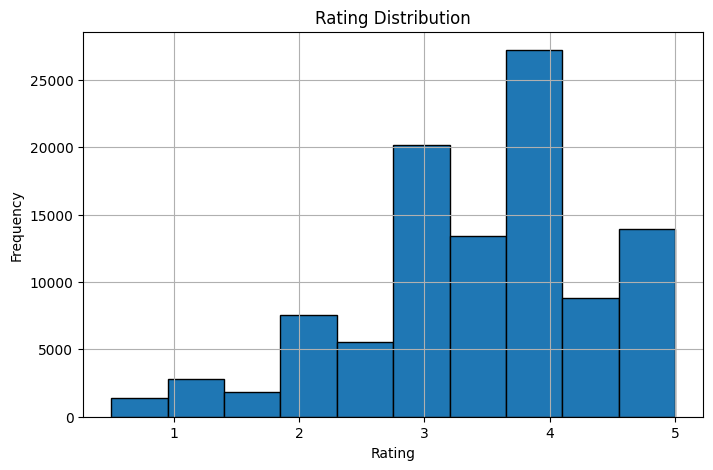

In [79]:
plt.figure(figsize=(8,5))
master_df["rating"].hist(bins=10, edgecolor="black")
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()

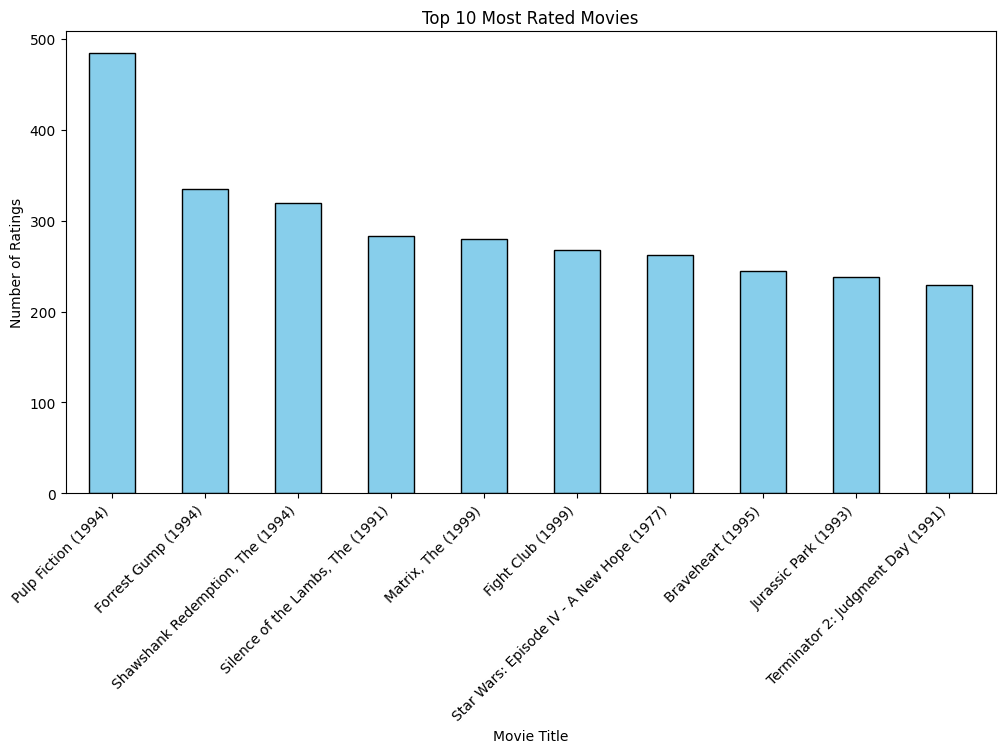

In [80]:
top_movies = master_df.groupby("title")["rating"].count().sort_values(ascending=False).head(10)
plt.figure(figsize=(12,6))
top_movies.plot(kind="bar", color="skyblue", edgecolor="black")
plt.title("Top 10 Most Rated Movies")
plt.xlabel("Movie Title")
plt.ylabel("Number of Ratings")
plt.xticks(rotation=45, ha="right")
plt.show()

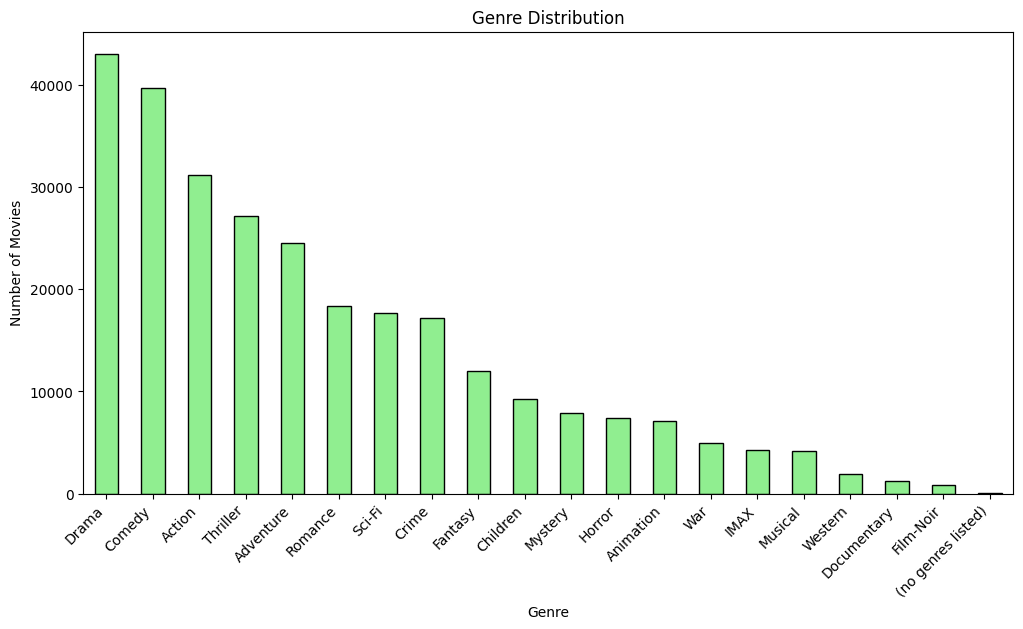

In [81]:
genre_counts = master_df["genres"].str.split("|").explode().value_counts()
plt.figure(figsize=(12,6))
genre_counts.plot(kind="bar", color="lightgreen", edgecolor="black")
plt.title("Genre Distribution")
plt.xlabel("Genre")
plt.ylabel("Number of Movies")
plt.xticks(rotation=45, ha="right")
plt.show()

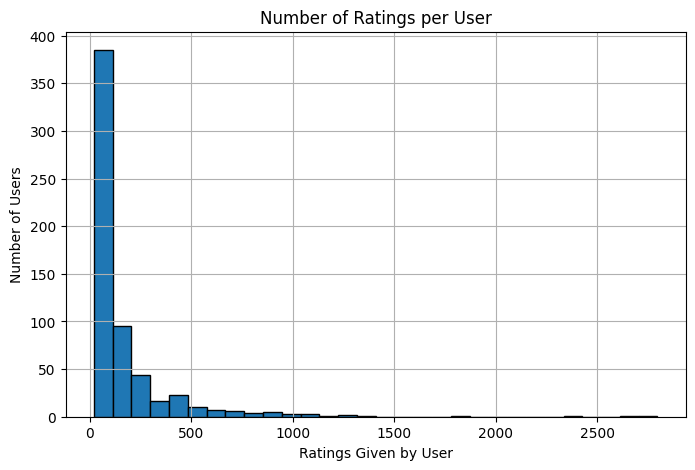

In [82]:
ratings_per_user = master_df.groupby("userId")["rating"].count()
plt.figure(figsize=(8,5))
ratings_per_user.hist(bins=30, edgecolor="black")
plt.title("Number of Ratings per User")
plt.xlabel("Ratings Given by User")
plt.ylabel("Number of Users")
plt.show()

In [83]:
movies = master_df[['title', 'genres']].drop_duplicates().reset_index(drop=True)
movies.head()

,title,genres
0,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,Grumpier Old Men (1995),Comedy|Romance
2,Heat (1995),Action|Crime|Thriller
3,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


In [84]:
movies["genres"] = movies["genres"].str.replace("|", " ", regex=False)
movies.head()

,title,genres
0,Toy Story (1995),Adventure Animation Children Comedy Fantasy
1,Grumpier Old Men (1995),Comedy Romance
2,Heat (1995),Action Crime Thriller
3,Seven (a.k.a. Se7en) (1995),Mystery Thriller
4,"Usual Suspects, The (1995)",Crime Mystery Thriller


In [85]:
cv = CountVectorizer()

feature_matrix = cv.fit_transform(movies["genres"])

In [86]:
feature_matrix.shape


(9716, 24)

In [87]:
similarity = cosine_similarity(feature_matrix)

similarity.shape

(9716, 9716)

In [88]:
def recommend_movies(movie_title, num_recommendations=10):
    
    if movie_title not in movies["title"].values:
        print("Movie not found in the dataset.")
        return

    movie_index = movies[movies["title"] == movie_title].index[0]

    similarity_scores = list(enumerate(similarity[movie_index]))
    similarity_scores = sorted(similarity_scores, key=lambda x: x[1], reverse=True)

    recommended_movies = []
    seen = set()

    print(f"\nTop {num_recommendations} movies similar to '{movie_title}':\n")

    for movie in similarity_scores[1:]:
        title = movies.iloc[movie[0]]["title"]

        if title not in seen:
            print(title)
            recommended_movies.append(title)
            seen.add(title)

        if len(recommended_movies) == num_recommendations:
            break

    return recommended_movies

In [89]:
recommend_movies("Toy Story (1995)")


Top 10 movies similar to 'Toy Story (1995)':

Toy Story 2 (1999)
Monsters, Inc. (2001)
Antz (1998)
Adventures of Rocky and Bullwinkle, The (2000)
Emperor's New Groove, The (2000)
Shrek the Third (2007)
The Good Dinosaur (2015)
Asterix and the Vikings (Astérix et les Vikings) (2006)
Tale of Despereaux, The (2008)
Moana (2016)


['Toy Story 2 (1999)',
 'Monsters, Inc. (2001)',
 'Antz (1998)',
 'Adventures of Rocky and Bullwinkle, The (2000)',
 "Emperor's New Groove, The (2000)",
 'Shrek the Third (2007)',
 'The Good Dinosaur (2015)',
 'Asterix and the Vikings (Astérix et les Vikings) (2006)',
 'Tale of Despereaux, The (2008)',
 'Moana (2016)']

In [90]:
recommend_movies("Toy Story (1995)")


Top 10 movies similar to 'Toy Story (1995)':

Toy Story 2 (1999)
Monsters, Inc. (2001)
Antz (1998)
Adventures of Rocky and Bullwinkle, The (2000)
Emperor's New Groove, The (2000)
Shrek the Third (2007)
The Good Dinosaur (2015)
Asterix and the Vikings (Astérix et les Vikings) (2006)
Tale of Despereaux, The (2008)
Moana (2016)


['Toy Story 2 (1999)',
 'Monsters, Inc. (2001)',
 'Antz (1998)',
 'Adventures of Rocky and Bullwinkle, The (2000)',
 "Emperor's New Groove, The (2000)",
 'Shrek the Third (2007)',
 'The Good Dinosaur (2015)',
 'Asterix and the Vikings (Astérix et les Vikings) (2006)',
 'Tale of Despereaux, The (2008)',
 'Moana (2016)']

In [91]:
recommend_movies("Jumanji (1995)")


Top 10 movies similar to 'Jumanji (1995)':

Return to Oz (1985)
NeverEnding Story, The (1984)
NeverEnding Story III, The (1994)
Harry Potter and the Sorcerer's Stone (a.k.a. Harry Potter and the Philosopher's Stone) (2001)
Jumanji (1995)
Indian in the Cupboard, The (1995)
Chronicles of Narnia: The Lion, the Witch and the Wardrobe, The (2005)
Pan (2015)
Golden Compass, The (2007)
Chronicles of Narnia: Prince Caspian, The (2008)


['Return to Oz (1985)',
 'NeverEnding Story, The (1984)',
 'NeverEnding Story III, The (1994)',
 "Harry Potter and the Sorcerer's Stone (a.k.a. Harry Potter and the Philosopher's Stone) (2001)",
 'Jumanji (1995)',
 'Indian in the Cupboard, The (1995)',
 'Chronicles of Narnia: The Lion, the Witch and the Wardrobe, The (2005)',
 'Pan (2015)',
 'Golden Compass, The (2007)',
 'Chronicles of Narnia: Prince Caspian, The (2008)']

In [92]:
recommend_movies("Heat (1995)")


Top 10 movies similar to 'Heat (1995)':

Batman (1989)
Shaft (2000)
Kill Bill: Vol. 1 (2003)
Die Hard: With a Vengeance (1995)
Net, The (1995)
Natural Born Killers (1994)
Bourne Supremacy, The (2004)
xXx (2002)
Bourne Ultimatum, The (2007)
Ronin (1998)


['Batman (1989)',
 'Shaft (2000)',
 'Kill Bill: Vol. 1 (2003)',
 'Die Hard: With a Vengeance (1995)',
 'Net, The (1995)',
 'Natural Born Killers (1994)',
 'Bourne Supremacy, The (2004)',
 'xXx (2002)',
 'Bourne Ultimatum, The (2007)',
 'Ronin (1998)']

In [93]:
recommend_movies("GoldenEye (1995)")


Top 10 movies similar to 'GoldenEye (1995)':

Con Air (1997)
Goldfinger (1964)
From Russia with Love (1963)
Dr. No (1962)
Live and Let Die (1973)
Thunderball (1965)
Man with the Golden Gun, The (1974)
GoldenEye (1995)
Broken Arrow (1996)
Cliffhanger (1993)


['Con Air (1997)',
 'Goldfinger (1964)',
 'From Russia with Love (1963)',
 'Dr. No (1962)',
 'Live and Let Die (1973)',
 'Thunderball (1965)',
 'Man with the Golden Gun, The (1974)',
 'GoldenEye (1995)',
 'Broken Arrow (1996)',
 'Cliffhanger (1993)']

In [94]:
recommend_movies("Seven (a.k.a. Se7en) (1995)")


Top 10 movies similar to 'Seven (a.k.a. Se7en) (1995)':

Rear Window (1954)
Saboteur (1942)
Memento (2000)
Just Cause (1995)
Old Boy (2003)
Mortal Thoughts (1991)
Pacific Heights (1990)
Absolute Power (1997)
Enemy (2013)
Blow Out (1981)


['Rear Window (1954)',
 'Saboteur (1942)',
 'Memento (2000)',
 'Just Cause (1995)',
 'Old Boy (2003)',
 'Mortal Thoughts (1991)',
 'Pacific Heights (1990)',
 'Absolute Power (1997)',
 'Enemy (2013)',
 'Blow Out (1981)']

In [95]:
recommend_movies("Toy Story (1995)")
recommend_movies("Jumanji (1995)")
recommend_movies("Heat (1995)")
recommend_movies("GoldenEye (1995)")
recommend_movies("Apollo 13 (1995)")


Top 10 movies similar to 'Toy Story (1995)':

Toy Story 2 (1999)
Monsters, Inc. (2001)
Antz (1998)
Adventures of Rocky and Bullwinkle, The (2000)
Emperor's New Groove, The (2000)
Shrek the Third (2007)
The Good Dinosaur (2015)
Asterix and the Vikings (Astérix et les Vikings) (2006)
Tale of Despereaux, The (2008)
Moana (2016)

Top 10 movies similar to 'Jumanji (1995)':

Return to Oz (1985)
NeverEnding Story, The (1984)
NeverEnding Story III, The (1994)
Harry Potter and the Sorcerer's Stone (a.k.a. Harry Potter and the Philosopher's Stone) (2001)
Jumanji (1995)
Indian in the Cupboard, The (1995)
Chronicles of Narnia: The Lion, the Witch and the Wardrobe, The (2005)
Pan (2015)
Golden Compass, The (2007)
Chronicles of Narnia: Prince Caspian, The (2008)

Top 10 movies similar to 'Heat (1995)':

Batman (1989)
Shaft (2000)
Kill Bill: Vol. 1 (2003)
Die Hard: With a Vengeance (1995)
Net, The (1995)
Natural Born Killers (1994)
Bourne Supremacy, The (2004)
xXx (2002)
Bourne Ultimatum, The (2007)

['Life of Pi (2012)',
 'Noah (2014)',
 'Captain Phillips (2013)',
 'Harry Potter and the Order of the Phoenix (2007)',
 'Easy Rider (1969)',
 'Stand by Me (1986)',
 'The Revenant (2015)',
 'Man Who Would Be King, The (1975)',
 'Black Robe (1991)',
 'Rabbit-Proof Fence (2002)']

In [96]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

...

def recommend_movies(movie_name):
    ...

In [97]:
recommend_movies("Toy Story (1995)")
recommend_movies("Jumanji (1995)")
recommend_movies("Heat (1995)")
recommend_movies("GoldenEye (1995)")
recommend_movies("Apollo 13 (1995)")
recommend_movies("Forrest Gump (1994)")
recommend_movies("The Matrix (1999)")
recommend_movies("Pulp Fiction (1994)")
recommend_movies("Titanic (1997)")
recommend_movies("Random Movie")

In [98]:
def load_dataset():
    return movies

def preprocess_data():
    movies["genres"] = movies["genres"].fillna("")
    return movies

def generate_similarity_matrix():
    cv = CountVectorizer(stop_words="english")
    vectors = cv.fit_transform(movies["genres"]).toarray()
    similarity = cosine_similarity(vectors)
    return similarity

def display_recommendations(movie_title):
    recommendations = recommend_movies(movie_title)
    return recommendations

In [99]:
import numpy as np

np.save("similarity_matrix.npy", similarity)

print("Similarity matrix saved successfully!")

Similarity matrix saved successfully!


In [100]:
interaction_matrix = master_df.pivot_table(
    index="userId",
    columns="movieId",
    values="rating"
).fillna(0)

interaction_matrix.head()

movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,4.0,0.0,4.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [101]:
from sklearn.metrics.pairwise import cosine_similarity

movie_similarity = cosine_similarity(interaction_matrix.T)

movie_similarity_df = pd.DataFrame(
    movie_similarity,
    index=interaction_matrix.columns,
    columns=interaction_matrix.columns
)

print("Movie similarity matrix created successfully!")

Movie similarity matrix created successfully!


In [102]:
def collaborative_recommend(movie_title, top_n=10):

    if movie_title not in master_df["title"].values:
        return "Movie not found in the dataset."

    movie_id = master_df.loc[
        master_df["title"] == movie_title, "movieId"
    ].iloc[0]

    similar_movies = movie_similarity_df[movie_id].sort_values(ascending=False)

    recommendations = []

    for movie in similar_movies.index[1:]:
        title = master_df.loc[
            master_df["movieId"] == movie, "title"
        ].iloc[0]

        if title not in recommendations:
            recommendations.append(title)

        if len(recommendations) == top_n:
            break

    return recommendations

In [103]:
print(collaborative_recommend("Toy Story (1995)"))

['Toy Story 2 (1999)', 'Jurassic Park (1993)', 'Independence Day (a.k.a. ID4) (1996)', 'Star Wars: Episode IV - A New Hope (1977)', 'Forrest Gump (1994)', 'Lion King, The (1994)', 'Star Wars: Episode VI - Return of the Jedi (1983)', 'Mission: Impossible (1996)', 'Groundhog Day (1993)', 'Back to the Future (1985)']


In [104]:
print(collaborative_recommend("Jumanji (1995)"))
print(collaborative_recommend("Heat (1995)"))
print(collaborative_recommend("Forrest Gump (1994)"))
print(collaborative_recommend("Pulp Fiction (1994)"))
print(collaborative_recommend("Matrix, The (1999)"))
print(collaborative_recommend("Apollo 13 (1995)"))
print(collaborative_recommend("GoldenEye (1995)"))
print(collaborative_recommend("Titanic (1997)"))
print(collaborative_recommend("Random Movie"))

['Lion King, The (1994)', 'Mrs. Doubtfire (1993)', 'Mask, The (1994)', 'Jurassic Park (1993)', 'Home Alone (1990)', 'Nightmare Before Christmas, The (1993)', 'Aladdin (1992)', 'Beauty and the Beast (1991)', 'Ace Ventura: When Nature Calls (1995)', 'Santa Clause, The (1994)']
['Rock, The (1996)', 'Twelve Monkeys (a.k.a. 12 Monkeys) (1995)', 'Léon: The Professional (a.k.a. The Professional) (Léon) (1994)', 'Casino (1995)', 'Fargo (1996)', 'Fugitive, The (1993)', 'Seven (a.k.a. Se7en) (1995)', 'Broken Arrow (1996)', 'Desperado (1995)', 'Independence Day (a.k.a. ID4) (1996)']
['Shawshank Redemption, The (1994)', 'Jurassic Park (1993)', 'Pulp Fiction (1994)', 'Braveheart (1995)', 'Silence of the Lambs, The (1991)', 'Apollo 13 (1995)', 'Matrix, The (1999)', 'Mrs. Doubtfire (1993)', "Schindler's List (1993)", 'Terminator 2: Judgment Day (1991)']
['Silence of the Lambs, The (1991)', 'Shawshank Redemption, The (1994)', 'Seven (a.k.a. Se7en) (1995)', 'Forrest Gump (1994)', 'Usual Suspects, The (

In [105]:
test_movies = [
    "Toy Story (1995)",
    "Jumanji (1995)",
    "Heat (1995)",
    "GoldenEye (1995)",
    "Apollo 13 (1995)",
    "Forrest Gump (1994)",
    "Matrix, The (1999)",
    "Pulp Fiction (1994)",
    "Titanic (1997)",
    "Random Movie"
]

for movie in test_movies:
    print("\nMovie:", movie)
    print(collaborative_recommend(movie))


Movie: Toy Story (1995)
['Toy Story 2 (1999)', 'Jurassic Park (1993)', 'Independence Day (a.k.a. ID4) (1996)', 'Star Wars: Episode IV - A New Hope (1977)', 'Forrest Gump (1994)', 'Lion King, The (1994)', 'Star Wars: Episode VI - Return of the Jedi (1983)', 'Mission: Impossible (1996)', 'Groundhog Day (1993)', 'Back to the Future (1985)']

Movie: Jumanji (1995)
['Lion King, The (1994)', 'Mrs. Doubtfire (1993)', 'Mask, The (1994)', 'Jurassic Park (1993)', 'Home Alone (1990)', 'Nightmare Before Christmas, The (1993)', 'Aladdin (1992)', 'Beauty and the Beast (1991)', 'Ace Ventura: When Nature Calls (1995)', 'Santa Clause, The (1994)']

Movie: Heat (1995)
['Rock, The (1996)', 'Twelve Monkeys (a.k.a. 12 Monkeys) (1995)', 'Léon: The Professional (a.k.a. The Professional) (Léon) (1994)', 'Casino (1995)', 'Fargo (1996)', 'Fugitive, The (1993)', 'Seven (a.k.a. Se7en) (1995)', 'Broken Arrow (1996)', 'Desperado (1995)', 'Independence Day (a.k.a. ID4) (1996)']

Movie: GoldenEye (1995)
['Die Hard: 

In [108]:
import pandas as pd

df = pd.read_csv("master_dataset.csv")
print(df.columns.tolist())

['userId', 'movieId', 'rating', 'timestamp_x', 'title', 'genres', 'imdbId', 'tmdbId', 'tag', 'timestamp_y', 'year', 'primary_genre', 'rating_count']
